<div class="alert alert-block alert-info">
<b>Number of points for this notebook:</b> 9
<br>
<b>Deadline:</b> January 27, 2026 (Tuesday) 23:59 (end of day)
</div>
<div class="alert alert-block alert-warning">
  <b>Important:</b> Only edit the cells marked "<samp># YOUR CODE HERE</samp>" in your final submission. 
  To avoid unintended changes, consider copying your solution into a fresh notebook.
  Grading is fully automated and there will be no manual corrections.
  <br>
  Submit a <b>single .zip</b> file containing all required files using "Upload File" (<b>not</b> "Upload Zip-Archive of Multiple Files").
</div>

# Exercise 10. Proximal Policy Optimization (PPO)

In this assignment, we will implement **Proximal Policy Optimization (PPO)** for the [CartPole-v1](https://gymnasium.farama.org/environments/classic_control/cart_pole/) environment from OpenAI Gym. Along the way, we will incorporate several important policy gradient concepts:

- **REINFORCE** (Monte Carlo Policy Gradient)
- **Importance Weighting (IW)** (For Off-Policy Learning)
- **Generalized Advantage Estimation (GAE)** (To Balance Bias and Variance)

## Understanding PPO

### Vanilla Policy Gradient (REINFORCE)
The **policy gradient** method optimizes the policy by maximizing the expected cumulative reward using the gradient:

$$
\sum_{h\geq 0} \nabla_\theta\log \pi_\theta(A_h|S_h) \cdot \sum_{t\geq h}\gamma^{t-h} r(S_t, A_t)
$$

Here, we compute gradients based on **Monte Carlo estimates** of rewards. This approach has high variance and slow convergence.


### Proximal Policy Optimization (PPO)
#### **GAE**
To reduce variance, we replace returns with **Generalized Advantage Estimation (GAE)**:

$$
A_t = \sum_{l=0}^{T} (\gamma \lambda)^l \delta_{t+l}
$$

where

$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$

This approach balances bias and variance in the advantage estimation.

#### **main update**
PPO refines the policy update by using a **clipped surrogate objective** that restricts how far the new policy can deviate from the old one:

$$
L^{CLIP}(\theta) = \mathbb{E} \left[ \min\left(r_t(\theta) A_t, \ \text{clip}\left(r_t(\theta), 1-\epsilon, 1+\epsilon\right) A_t\right) \right]
$$

with

$$
r_t(\theta) = \frac{\pi_{\theta}(a_t | s_t)}{\pi_{\theta_{\text{old}}}(a_t | s_t)}
$$

This clipping ensures that updates remain within a **trust region**, enhancing stability.


## 1. Setup

In [16]:
skip_training = True  # Set this flag to True before validation and submission

In [ ]:
# During evaluation, this cell sets skip_training to True
# skip_training = True

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="darkgrid")

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

The following helper function that evaluates a given policy is provided.

In [3]:
def evaluate_policy(policy, env_name, seed=42):
    env_test = gym.make(env_name)
    # env_test.seed(seed)
    state, _ = env_test.reset()
    done = False
    total_reward = 0
    while not done:
        state = torch.FloatTensor(state).unsqueeze(0)
        dist = policy(state)
        next_state, reward, done, _, _ = env_test.step(dist.sample().item())
        state = next_state
        total_reward += reward
    return total_reward

## 2. Defining the Policy and Value Networks

We start from the policy network, which decides on the actions to take, and the value network, which estimates the returns. You need to implement both neural networks.

### Policy Network

Complete the initialization of the **Policy Network**, which maps states to action probabilities.

The network should consist of **three fully connected layers**:

1. An **input layer** that takes in `state_dim` and outputs **128 neurons**.
2. A **hidden layer** with **128 neurons**.
3. A **final output layer** that maps to `action_dim`, producing logits for each possible action.
4. The activation function for the hidden layers should be ReLU (torch.relu).
5. Implement the forward pass to return a Categorical distribution given state inputs.

**Hint:** The constructor takes `state_dim` and `action_dim` as arguments, representing the dimensions
of the state space and action space, respectively.

### Value Network

Complete the initialization of the **Value Network**, which maps states to their estimated values.

The network consists of **three fully connected layers**:

1. An **input layer** that takes `state_dim` and outputs **128 neurons**.
2. A **hidden layer** with **128 neurons**.
3. A **final output layer** that produces a **single scalar value** representing the state's estimated value.
4. Activation function for the hidden layers should be ReLU (torch.relu).


**Hint:** The constructor takes `state_dim` as an argument, representing the dimension of the state space.

In [ ]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        """
        Initialize the Policy Network that maps states to action probabilities.
        
        Args:
            state_dim: Dimension of the state space.
            action_dim: Dimension of the action space.
        """
        super(PolicyNetwork, self).__init__()
        self.capa_1 = nn.Linear(in_features=state_dim,out_features=128)
        self.capa_hidden = nn.Linear(in_features=128,out_features=128)
        self.out_layer = nn.Linear(in_features=128,out_features=action_dim)
        layers = [self.capa_1,self.capa_hidden,self.out_layer]
        for layer in layers: 
            torch.nn.init.kaiming_uniform_(layer.weight,nonlinearity='relu')
            torch.nn.init.zeros_(layer.bias)
        

    def forward(self, x):
        """
        Forward pass through the policy network.
        
        Args:
            x of shape (batch_size, state_dim): Input state tensor.

        Returns:
            dist: torch.distributions.Categorical distribution over actions,
                  parameterized by logits of shape (batch_size, action_dim).
        """
        # YOUR CODE HERE
        o1 = torch.relu(self.capa_1(x))
        o2 = torch.relu(self.capa_hidden(o1))
        logits = self.out_layer(o2)
        return Categorical(logits=logits)

class ValueNetwork(nn.Module):
    def __init__(self, state_dim):
        """
        Initialize the Value Network that estimates state values.
        
        Args:
            state_dim: Dimension of the state space.
        """
        super(ValueNetwork, self).__init__()
        self.capa_1 = nn.Linear(in_features=state_dim,out_features=128)
        self.capa_hidden = nn.Linear(in_features=128,out_features=128)
        self.out_layer = nn.Linear(in_features=128,out_features=1)
        layers = [self.capa_1,self.capa_hidden,self.out_layer]
        for layer in layers: 
            torch.nn.init.kaiming_uniform_(layer.weight,nonlinearity='relu')
            torch.nn.init.zeros_(layer.bias)
        

    def forward(self, x):
        """
        Forward pass through the value network.
        
        Args:
            x of shape (batch_size, state_dim): Input state tensor.

        Returns:
            value of shape (batch_size, 1): Estimated state value (one scalar per sample).
        """
        # YOUR CODE HERE
        o1 = torch.relu(self.capa_1(x))
        o2 = torch.relu(self.capa_hidden(o1))
        value = self.out_layer(o2)
        return value


In [ ]:
# This cell tests the Policy and Value network interface and shapes

The function `compute_advantages` calculates **returns** using the **Generalized Advantage Estimation (GAE)** method.
GAE helps reduce variance while maintaining bias efficiency in reinforcement learning algorithms like PPO.

This function follows a **backward recursion** process:

1. The function receives `rewards`, `masks`, and `values`, which are **lists** representing a **trajectory** (a sequence of states and rewards).
2. The **masks** are used to handle terminal states (they are 0 if the episode ends and 1 otherwise).
3. It calculates **delta** ($\delta_t$), which is the temporal difference (TD) error.
4. The function accumulates **advantages** using the **recursive formula** for GAE.
5. Finally, it stores the **returns** (advantage + value function) for each step.

**Notes:**
- As the recursion computation may be a bit tricky, we can adopt a simple **for-loop** calculation.
- The function is named `compute_advantages`, but it actually calculates **returns** (advantage + value).
- The use of **masks** ensures that advantage propagation stops at the end of an episode.

As a reference for your understanding, here is how **REINFORCE** computes returns in a recursion way:

  ```python
  def compute_returns(rewards, gamma=0.99):
      returns = []
      G = 0
      for reward in reversed(rewards):
          G = reward + gamma * G
          returns.insert(0, G)
      return returns
  ```

**Hints:** You need to implement steps 3 to 5 of the backward recursion process below. Refer to the aforementioned TD error formula and note that the advantage is computed recursively.

In [11]:
def compute_advantages(next_value, rewards, masks, values, gamma=0.99, lambda_gae=0.95):
    values = values + [next_value]  # Append bootstrap value for last state
    advantages = 0
    returns = []

    for step in reversed(range(len(rewards))):  # Iterate in reverse (backward pass)
        # YOUR CODE HERE
        delta_t = rewards[step] + gamma*values[step+1]*masks[step] - values[step]
        advantages = delta_t + gamma*lambda_gae*masks[step]*advantages
        return_t = advantages + values[step]
        returns.append(return_t) 
    returns.reverse()    

    return returns #Debido a que antes nos daban el orden cambio asi que hay que tener cuidado!!

In [ ]:
# This cell tests compute_advantages

## 3. Implementing the Training Loop

Training in PPO involves collecting data from the environment, computing advantages, and updating the policy and value networks.

1. `ppo_iter()`: This function generates mini-batches from the collected data, which are then used for gradient updates. This function is provided to you.

2. `ppo_update()`: This function optimizes the policy and value networks using the Proximal Policy Optimization algorithm. This function applies the core PPO algorithm, using the experiences collected from the environment to perform multiple epochs of updates on the policy and value networks. You need to implement the core parts.


In [12]:
def ppo_iter(mini_batch_size, states, actions, log_probs, returns, advantage):
    batch_size = states.size(0)
    mini_batches = []

    for _ in range(batch_size // mini_batch_size):
        rand_ids = torch.randint(0, batch_size, (mini_batch_size,))
        mini_batch = states[rand_ids], actions[rand_ids], log_probs[rand_ids], returns[rand_ids], advantage[rand_ids]
        mini_batches.append(mini_batch)

    return mini_batches

The `ppo_update()` function should perform the optimization of the policy and value networks using the Proximal Policy Optimization (PPO) algorithm.
You'll need to compute the ratio of new and old policy probabilities, apply the clipping technique, and calculate the losses for both the actor (policy network) and critic (value network).

**Instructions:**

1. Iterate over the number of PPO epochs, which is the number of optimizer.step() with the current collected data.
2. In each epoch, iterate over the mini-batches of experiences.
3. Calculate the new log probabilities of the actions taken, using the policy network.
4. Compute the ratio of new to old probabilities.
5. Apply the PPO clipping technique to the computed ratios.
6. Calculate the actor (policy) and critic (value) losses. You need to check the consistency for variable shapes before calculating the losses.
	- **Compute the actor loss:**
		- The **surrogate objective** function is:
			$$ L^{\text{clip}} = -\min(\text{ratio} \cdot \text{advantage}, \text{clipped\_ratio} \cdot \text{advantage}) $$
		- The final **actor loss** is the mean of this objective.

	- **Compute the critic loss:**
		- The value network should minimize the difference between predicted and actual returns:
			$$ L^{\text{critic}} = (\text{return} - \text{value})^2 $$
		- The final **critic loss** is the mean of this objective.

7. Combine the losses and perform a backpropagation step.

**Hints:**

- Use `policy_net(state)` to get the distribution over actions for the given states.
- The `dist.log_prob(action)` method calculates the log probabilities of the taken actions according to the current policy.
- The ratio is computed as the exponential of the difference between new and old log probabilities (`(new_log_probs - old_log_probs).exp()`).
- Use `torch.clamp(ratio, 1.0 - clip_param, 1.0 + clip_param)` to clip the ratio between `[1-clip_param, 1+clip_param]`.
- The actor loss is the negative minimum of the clipped and unclipped objective, averaged over all experiences in the mini-batch.
- The critic loss is the mean squared error between the returns and the value estimates from the value network.
- Remember to zero the gradients of the optimizer before the backpropagation step with `optimizer.zero_grad()`.
- After computing the loss and performing backpropagation with `loss.backward()`, take an optimization step with `optimizer.step()`.


In [13]:
def ppo_update(policy_net, value_net, optimizer, ppo_epochs, mini_batch_size, states, actions, log_probs, returns, advantages, clip_param=0.2):
    for _ in range(ppo_epochs):
        for state, action, old_log_probs, return_, advantage in ppo_iter(mini_batch_size, states, actions, log_probs, returns, advantages):
            dist = policy_net(state)
            new_log_probs = dist.log_prob(action)
            # YOUR CODE HERE
            ratio = (new_log_probs - old_log_probs).exp()
            clip_ratio = torch.clamp(ratio,1.0 - clip_param,1.0 + clip_param)
            L_clip = - torch.min(ratio*advantage,clip_ratio*advantage)
            actor_loss = L_clip.mean()
            L_critic = torch.pow(return_ - value_net(state),2)
            critic_loss = L_critic.mean()
            loss = 0.5 * critic_loss + actor_loss  # You can freely adjust the weight of the critic loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

In [8]:
# This cell tests ppo_update

Next, we will implement the **main training loop**, which collects data from the environment, computes advantages, and updates the policy and value networks.

You must collect a fixed number of transitions (2048) by interacting with the environment using the **current policy**.

For each environment step, you should:

1. Convert the current state to a PyTorch tensor.
2. Use the policy network to obtain an **action distribution**.
3. **Sample an action** from this distribution.
4. **Execute the action** in the environment.
5. Store the following quantities for PPO training:
   - the current state
   - the sampled action
   - the log-probability of the action under the current policy
   - the estimated state value from the value network
   - the received reward
   - a mask indicating whether the episode terminated (1 if not done, 0 if done)
6. If the episode ends, **reset the environment** before continuing.

These collected trajectories will later be used to compute advantages and perform the PPO update.

In [9]:
def train(env_name='CartPole-v1', num_steps=1000, mini_batch_size=8, ppo_epochs=4, threshold=400):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy_net = PolicyNetwork(state_dim, action_dim)
    value_net = ValueNetwork(state_dim)
    optimizer = optim.Adam(list(policy_net.parameters()) + list(value_net.parameters()), lr=3e-3)

    state, _ = env.reset()
    early_stop = False
    reward_list = []

    for step in range(num_steps):
        log_probs = []
        values = []
        states = []
        actions = []
        rewards = []
        masks = []

        # Collect samples under the current policy
        for _ in range(2048):
            # YOUR CODE HERE
            state_t = torch.tensor(np.array(state)).unsqueeze(0)
            dist = policy_net(state_t)
            action_t = dist.sample()
            log_prob_t = dist.log_prob(action_t)
            value_t = value_net(state_t)
            step_out = env.step(action_t.item())
            if len(step_out) == 5:
                next_state, reward, terminated, truncated, _ = step_out
                done = terminated or truncated
            else:
                next_state, reward, done, _ = step_out
            mask_t = 0.0 if done else 1.0
            states.append(state_t)
            actions.append(action_t)
            log_probs.append(log_prob_t)
            values.append(value_t)
            rewards.append(torch.tensor([reward]))
            masks.append(torch.tensor([mask_t]))
            if done:
                state, _ = env.reset()
            else:
                state = next_state

            

        next_state = torch.tensor(np.array(next_state), dtype=torch.float32).unsqueeze(0)  # Ensure proper conversion
        next_value = value_net(next_state)
        returns = compute_advantages(next_value, rewards, masks, values)

        returns = torch.cat(returns).detach()
        log_probs = torch.cat(log_probs).detach()
        values = torch.cat(values).detach()
        states = torch.cat(states)
        actions = torch.cat(actions)
        advantage = returns - values

        # Run PPO update for policy and value networks
        ppo_update(policy_net, value_net, optimizer, ppo_epochs, mini_batch_size, states, actions, log_probs, returns, advantage)

        if step % 1 == 0:
            test_reward = np.mean([evaluate_policy(policy_net, env_name) for _ in range(10)])
            print(f'Step: {step}\tReward: {test_reward}')
            reward_list.append(test_reward)
            if test_reward > threshold:
                print("Solved!")
                early_stop = True
                break
    return policy_net, value_net, early_stop, reward_list

## 4. Training and evaluation

The provided hyperparameters, if implemented correctly, should be able to make rewards higher than 400.

**Note:** Please try several times if you think your code is correct, the learning curves can have some variances over different runs. **Upload the best run you can get.**

In [14]:
threshold = 400

if not skip_training:
    policy_net, value_net, early_stop, reward_list = train(
        env_name='CartPole-v1',
        num_steps=100,
        mini_batch_size=16,
        ppo_epochs=8,
        threshold=threshold
    )

    # Save state dicts
    torch.save({
        'policy_state_dict': policy_net.state_dict(),
        'value_state_dict': value_net.state_dict(),
        'reward_list': reward_list,
        'early_stop': early_stop,
    }, '1_ppo_cartpole.pth')

else:
    checkpoint = torch.load('1_ppo_cartpole.pth', map_location=lambda storage, loc: storage, weights_only=False)

    # Recreate networks (architecture must match student implementation)
    env = gym.make('CartPole-v1')
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy_net = PolicyNetwork(state_dim, action_dim)
    value_net = ValueNetwork(state_dim)

    policy_net.load_state_dict(checkpoint['policy_state_dict'])
    value_net.load_state_dict(checkpoint['value_state_dict'])

    reward_list = checkpoint['reward_list']
    early_stop = checkpoint['early_stop']


Step: 0	Reward: 20.6
Step: 1	Reward: 26.2
Step: 2	Reward: 38.1
Step: 3	Reward: 45.3
Step: 4	Reward: 49.4
Step: 5	Reward: 24.0
Step: 6	Reward: 48.9
Step: 7	Reward: 50.5
Step: 8	Reward: 66.7
Step: 9	Reward: 74.3
Step: 10	Reward: 73.4
Step: 11	Reward: 89.1
Step: 12	Reward: 97.5
Step: 13	Reward: 98.5
Step: 14	Reward: 105.2
Step: 15	Reward: 110.2
Step: 16	Reward: 128.7
Step: 17	Reward: 135.0
Step: 18	Reward: 98.3
Step: 19	Reward: 106.2
Step: 20	Reward: 131.4
Step: 21	Reward: 140.2
Step: 22	Reward: 182.6
Step: 23	Reward: 119.6
Step: 24	Reward: 122.4
Step: 25	Reward: 108.6
Step: 26	Reward: 166.5
Step: 27	Reward: 155.7
Step: 28	Reward: 145.7
Step: 29	Reward: 146.5
Step: 30	Reward: 139.6
Step: 31	Reward: 115.7
Step: 32	Reward: 142.7
Step: 33	Reward: 129.7
Step: 34	Reward: 140.7
Step: 35	Reward: 152.6
Step: 36	Reward: 227.1
Step: 37	Reward: 229.1
Step: 38	Reward: 232.0
Step: 39	Reward: 261.2
Step: 40	Reward: 246.2
Step: 41	Reward: 249.6
Step: 42	Reward: 250.0
Step: 43	Reward: 421.7
Solved!


In [ ]:
# This cell tests PPO performance

### Plot the performance curves

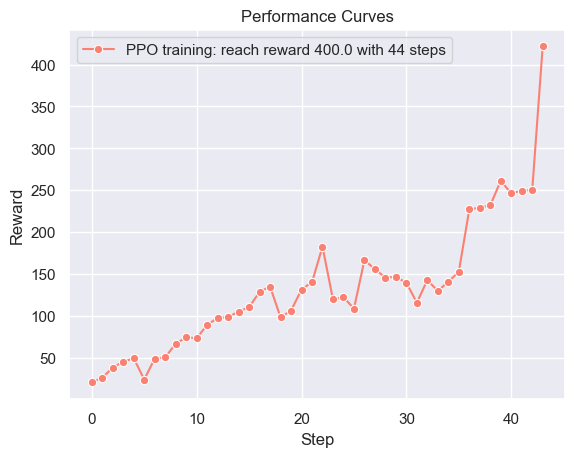

In [15]:
if not early_stop:
    print("Not solved in %d steps"%len(reward_list))

# Plot using Seaborn
sns.lineplot(x=np.arange(len(reward_list)), y=reward_list, color='salmon', marker='o', linestyle='-', label='PPO training: reach reward %.1f with %d steps'%(threshold, len(reward_list)))

# Optional: Adding titles and labels
plt.title('Performance Curves')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.legend()

# Show the plot
plt.show()

<div class="alert alert-block alert-info">
<b>Conclusion</b>
</div>

In this exercise, we implemented a Proximal Policy Optimization (PPO) agent from scratch, including the policy and value networks, on-policy data collection, and advantage estimation using GAE. We then trained the agent using the PPO clipped objective and evaluated its performance on a standard control task.